## Machine Learning

    Machine learning is a subset of AI, which provides machines with the ability to learn automatically and improve, without being explicitly programmed.
    It is a branch of AI that focuses on developing Algorithms and statistical models that enabnles computers to perform tasks without explicit instruction. 
    A computer program is said to learn by experience(E), when performing some tasks(T), and measure performance(P), to enable it perform the same task better.

#### Needs for ML
* increase in amount of data generated
* Cloud computing
* Need for automation
* IOT devices etc.

##### How ML works

DATA--->Machine training---->Model Building---->Predict Outcome

Machine learning is divided into four major subsets

* Supervised Learning
* Unsupervised Learning
* Deep Learning
* Re-inforced Learning

## Supervised Learning: 
    This is a subset of ML, where the model is expected to give outputs, based on the inputs, parsed to it. It takes on input, output pairs, and observes patterns and relationship in training.

### Terms Associated with Machine Learning

* Algorithms: This is a set of step-by-step instructions or rules and statistical techniques designed to perform a specific task or solve a particular problem.
* Model: This is a mathematical representation of a process or relationship that learns patterns from data.
* Predictor Variable: This is a variable used in statistical modeling and ML to predict the outcome of another variable (predicted). otherwise called "input, x"
* Response Variable: This is the predicted outcome of the model. otherwise called "target, predicted, output, y"

##### Linear Regression:
    This is the modelling of the relationship between a variable and another, or a variable and a set of other variables.

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np

In [2]:
# data = pd.read_csv('simple_linear_regression.csv')
data = pd.read_csv(r'C:\Users\USER\Downloads\simple_linear_regression.csv')

In [3]:
data.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


#### Perform Descriptive statistics

In [4]:
data.describe()

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


#### Perform inferential statistics 

In [5]:
x = data['SAT']
y = data['GPA']

In [6]:
#Considering that the two values are continous, we use pearson correlation
#import model for test
import scipy.stats as stats
corr, p_value = stats.pearsonr(x, y)


In [7]:
print(f' P value {p_value.round(5)}, \n', 
     f'Correlation score {corr}')   #Considering the outcome you can say that the
                                   #P_val holds a strong evidence against the null hypothesis

 P value 0.0, 
 Correlation score 0.6371843648401909


#### Build model

    Statsmodels.api is a module used to build statistic models like linear regression, logistics etc

We would build two models, one with constant and another without constant

MODEL WITH CONSTANT

In [8]:
import statsmodels.api as sm

In [9]:
#add constant
x1 = sm.add_constant(x)

In [10]:
print(f'X without constant {x.head()}', f'X with constant{x1.head()}')

X without constant 0    1714
1    1664
2    1760
3    1685
4    1693
Name: SAT, dtype: int64 X with constant   const   SAT
0    1.0  1714
1    1.0  1664
2    1.0  1760
3    1.0  1685
4    1.0  1693


In [11]:
model = sm.OLS(y, x1).fit() #OLS is a function used to build linear regression models
                            #It models the relationship between linearly-related variables
                            #It takes two variable the predicted and the predicto

#### Describe model

In [12]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     56.05
Date:                Thu, 29 May 2025   Prob (F-statistic):           7.20e-11
Time:                        13:40:20   Log-Likelihood:                 12.672
No. Observations:                  84   AIC:                            -21.34
Df Residuals:                      82   BIC:                            -16.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2750      0.409      0.673      0.503      -0.538       1.088
SAT            0.0017      0.000      7.487      0.000       0.001       0.002
==============================================================================
Omnibus:                       12.839   Durbin-Watson:                   0.950
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.155
Skew:                          -0.722   Prob(JB):                     0.000310
Kurtosis:                       4.590   Cond. No.                     3.29e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.29e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Make predictions

In [13]:
print(f' Actual value of y{y[:1]}\n', 
      f'Predicted value of y {model.predict(x1[:1])}')

 Actual value of y0    2.4
Name: GPA, dtype: float64
 Predicted value of y 0    3.11289
dtype: float64


## Observing the relationship between x and y

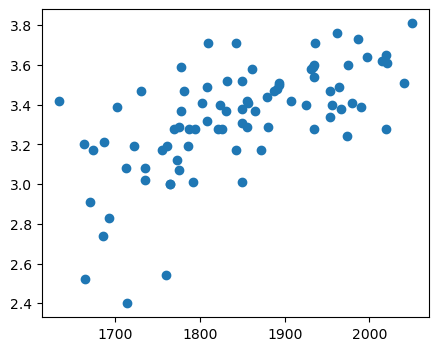

In [14]:
import matplotlib.pyplot as plt
#Using scatter plot
plt.figure(figsize = (5,4))
plt.scatter(x,y)
plt.show()

#### Draw the regression line 

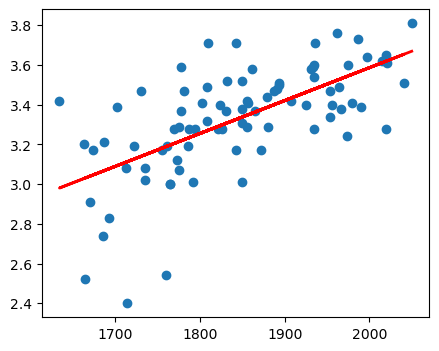

In [15]:
plt.figure(figsize = (5,4))
plt.subplot(1,1,1)
plt.scatter(x,y)
plt.subplot(1,1,1)
plt.plot(x, model.predict(x1), lw = 2, c = 'r')
plt.show()

MODEL WITHOUT CONSTANT

In [16]:
model1 = sm.OLS(y, x).fit()

In [17]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    GPA   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.996
Method:                 Least Squares   F-statistic:                          2.120e+04
Date:                Thu, 29 May 2025   Prob (F-statistic):                   9.38e-102
Time:                        13:40:21   Log-Likelihood:                          12.440
No. Observations:                  84   AIC:                                     -22.88
Df Residuals:                      83   BIC:                                     -20.45
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
SAT            0.0018   1.24e-05    145.594      0.000       0.002       0.002
==============================================================================
Omnibus:                        9.848   Durbin-Watson:                   1.116
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               11.422
Skew:                          -0.594   Prob(JB):                      0.00331
Kurtosis:                       4.361   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

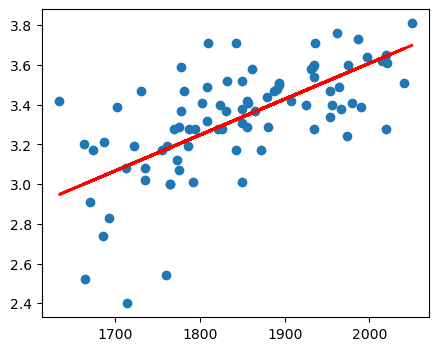

In [18]:
plt.figure(figsize = (5,4))
plt.subplot(1,1,1)
plt.scatter(x,y)
plt.subplot(1,1,1)
plt.plot(x, model1.predict(x), lw = 2, c = 'r')
plt.show()

In [19]:
model1.predict(x[10:11]), y[10:11]

(10    3.130405
 dtype: float64,
 10    3.02
 Name: GPA, dtype: float64)